In [1]:
# Author: Arthur Prigent
# Email: arthur.prigent@univ-brest.fr

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import datetime as dt
import gsw
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
import ArcTools as Atools
import pandas as pd

# Vertical grid from ISAS

In [2]:
# read
dir_clim = '/data0/user/aprigent/ISAS/ISAS17_Mask.nc'
mask = xr.open_dataset(dir_clim)
zi = mask.depthCFD.data


# Vertical interpolation function

In [3]:
def interp_prof(x_old, y_old, x_new):

    # Import interpolation methods from SciPy
    # (only Akima1DInterpolator is actually used below)
    from scipy.interpolate import Akima1DInterpolator
    
    yi = []   # list to store interpolated profiles
    iyi = []  # list to store indices of successfully interpolated profiles
    
    # Loop over each profile (rows of y_old)
    for i in range(0, y_old.shape[0]):
        
        # Extract the i-th profile
        y = y_old[i, :]
        x = x_old[i, :]
        
        # Identify non-NaN values in y and x_old
        inans_y = ~np.isnan(y)
        inans_x = ~np.isnan(x)
       
        # print(len(inans_x),len(inans_y))
        # Keep only points where both x and y are valid
        inans = inans_y * inans_x
        
        
        # Proceed only if there are any valid points
        if np.any(inans):
            
            # Need at least 2 valid points for interpolation
            if len(y[inans]) > 1:
                # print(i)

                # Create Akima spline interpolator using valid data points
                try :
                    spl = Akima1DInterpolator(x[inans], y[inans])
                
                
                    # Interpolate profile onto the new x grid
                    prof = spl(x_new)
                
                    # Store interpolated profile and its original index
                    yi.append(prof)
                    iyi.append(i)
                except ValueError:
                    continue
                
    # Return:
    # - array of interpolated profiles
    # - array of indices of profiles that were successfully interpolated
    return np.array(yi), np.array(iyi)


### List ARGO profiles

In [4]:
argo_path = '/data0/user/aprigent/ARGO/Arctic/'
list_file = glob.glob(argo_path + '*_prof.nc')


In [5]:
len(list_file)

573

# Start looping on ARGO individual files

In [6]:

data_out = '/data0/user/aprigent/ARGO/Arctic/'

n_qc8 = []
n_prof = []
interpolated_position_file = []
nb_temp_prof_init = 0
nb_psal_prof_init = 0

nb_temp_prof_qc_interp = 0
nb_psal_prof_qc_interp = 0
ref_time = dt.datetime(1950,1,1).toordinal()
for f in list_file:
    print('---------')
    
    print('    ')
    print(f)
    itp = xr.open_dataset(f,decode_times=False)
    
    platform_num = int(itp.PLATFORM_NUMBER[0].values)

    if platform_num in [6903119, 6903143,6903144,6903145,6903146,
                                  6903147,7901038,3902112,3902118,4903655,
                                  6903587,6903588,6903589,6904087,7900549,7902188]: # csv file at /data0/user/aprigent/ARGO
        
        print('will be treated in load_interp_ARGO_data_interp.ipynb')
        continue
    # --- TIME QC CHECK ---
    juld_qc = itp.JULD_QC.data
    qc_time = juld_qc == b'1'

    juld_ord = np.array([int(ref_time + t) for t in itp.JULD.data[qc_time]])

    if len(juld_ord) == 0:
        print('No QC time')
        continue
    
    if juld_ord[-1]> dt.datetime(1999,12,31).toordinal():
        
        print('Time check passed for:',f)
        pres = itp.PRES_ADJUSTED.data[qc_time]
        lat = itp.LATITUDE.data[qc_time]
        lon = itp.LONGITUDE.data[qc_time]
        psal= itp.PSAL_ADJUSTED.data[qc_time]
        temp=itp.TEMP_ADJUSTED.data[qc_time]
        nb_temp_prof_init += temp.shape[0]
        nb_psal_prof_init += psal.shape[0]
        psal_qc = itp.PSAL_ADJUSTED_QC.data[qc_time]
        temp_qc = itp.TEMP_ADJUSTED_QC.data[qc_time]
        data_mode = itp.DATA_MODE.data[qc_time]
        press_qc = itp.PRES_ADJUSTED_QC.data[qc_time]
        pos_qc = itp.POSITION_QC.data[qc_time]
        
        
        platform_id = np.array([int(p.decode().strip()) for p in itp.PLATFORM_NUMBER.values])
        platform_id = platform_id[qc_time]
        qc_press = press_qc == b'1'
        pres[~qc_press] = np.nan
        dep = -gsw.z_from_p(pres.T,lat).T
        
        
        
        qc1_pos = (pos_qc == b'1')
        
        if (pos_qc == b'8').any():
            
            print('This file has interpolated position:', f)
            interpolated_position_file.append(f)
            n_qc8.append((pos_qc == b'8').sum())
            n_prof.append(itp.N_PROF.shape[0])
        
        qc1_psal = psal_qc == b'1'
        qc1_temp = temp_qc == b'1'
        qc_mode = (data_mode == b'D')| (data_mode == b'A') #| (data_mode == b'r')

        qc_mode_2d_psal = np.broadcast_to(qc_mode[:, None], psal.shape)
        qc_mode_2d_temp = np.broadcast_to(qc_mode[:, None], temp.shape)
        qc_pos_2d_psal = np.broadcast_to(qc1_pos[:, None], psal.shape)
        qc_pos_2d_temp = np.broadcast_to(qc1_pos[:, None], temp.shape)
        
        final_mask_temp = ~(qc_pos_2d_temp & qc1_temp & qc_press & qc_mode_2d_temp)
        final_mask_psal = ~(qc_pos_2d_psal & qc1_psal & qc_press & qc_mode_2d_psal)

        
        psal[final_mask_psal] = np.nan
        temp[final_mask_temp] = np.nan     
        
        
        n_levels_temp = np.ones((dep.shape[0]))*dep.shape[1]
        n_levels_psal  = np.ones((dep.shape[0]))*dep.shape[1]
        
        sum_temp = np.nansum(temp,axis=1)
        sum_psal  = np.nansum(psal,axis=1)
        sum_dep = np.nansum(dep,axis=1)

        
        PSAL,ipsal = interp_prof(dep,psal,zi)
        TEMP,itemp = interp_prof(dep,temp,zi)

        TEMP[TEMP<-2] = np.nan
        TEMP[TEMP>30] = np.nan
        PSAL[PSAL<0] = np.nan
        PSAL[PSAL>40] = np.nan
        if len(itemp)!=0:
            print('TEMP mean = ',np.nanmean(TEMP))
            print('TEMP min = ',np.nanmin(TEMP))
            TIMEt = np.array(juld_ord)[itemp]
            LONt = lon[itemp]
            LATt = lat[itemp]
            sum_TEMP = sum_temp[itemp]
            n_levels_TEMP = n_levels_temp[itemp]
            sum_dep_TEMP = sum_dep[itemp]
            platform_TEMP = platform_id[itemp]
        
        nb_temp_prof_qc_interp += TEMP.shape[0]
        nb_psal_prof_qc_interp += PSAL.shape[0]
        
        if len(ipsal) != len(itemp):
            print('psal/temp dimension missmatch')
        if len(ipsal)!=0:
            TIMEs = np.array(juld_ord)[ipsal]
            LONs = lon[ipsal]
            LATs = lat[ipsal]
            sum_PSAL  = sum_psal[ipsal]
            n_levels_PSAL = n_levels_psal[ipsal]
            sum_dep_PSAL = sum_dep[ipsal]
            platform_PSAL = platform_id[ipsal]
        
            # save file PSAL
            ds = xr.Dataset({'latitude': (['prof'], LATs),
                             'longitude': (['prof'], LONs),
                             'time': (['prof'], TIMEs),
                             'salinity': (['prof','levels'], PSAL),
                             'platform_id': (['prof'], platform_PSAL),
                             'sum_salinity': (['prof'], sum_PSAL),
                             'sum_levels': (['prof'], sum_dep_PSAL),
                             'nb_levels': (['prof'], n_levels_PSAL),
                             'depth': (['levels'], zi)},
                            coords={'prof': (['prof'], np.arange(0,len(TIMEs))), 'levels':(['levels'], zi)})
            
            # global attributes
            ds.attrs['Comments'] = 'Argo float salinity profiles (data mode=D) interpolated on ISAS vertical levels using a Akima 1D interpolator scheme (scipy)'
            ds.attrs['Original file'] = f[33:]
            ds.attrs['title'] = 'Argo salinity profiles on ISAS vertical grid'
            ds.attrs['source'] = 'Argo'
            ds.attrs['history'] = 'Created with xarray'
            
            # variable attributes
            ds['latitude'].attrs = {'long_name':'Latitude','units':'degrees_north','standard_name':'latitude'}
            ds['longitude'].attrs = {'long_name':'Longitude','units':'degrees_east','standard_name':'longitude'}
            ds['time'].attrs = {'long_name':'Time', "units": "days since 0001-01-01 (Python datetime system)"}
            ds['salinity'].attrs = {'long_name':'Salinity (S78 - PSS)',
                                    'units':'1e-3',   # or 'psu'
                                    'standard_name':'sea_water_practical_salinity'}
            ds['depth'].attrs = {'long_name':'Depth','units':'m','positive':'down','standard_name':'depth'}
            ds['platform_id'].attrs = {'long_name':'Argo platform identifier'}
    
    
            ds.to_netcdf(data_out + f[33:-3] + '_ISAS_PSAL.nc')   
            
            # save file TEMP
            ds = xr.Dataset({'latitude': (['prof'], LATt),
                             'longitude': (['prof'], LONt),
                             'time': (['prof'], TIMEt),
                             'temperature': (['prof','levels'], TEMP),
                             'platform_id': (['prof'], platform_TEMP),
                             'sum_temperature': (['prof'], sum_TEMP),
                             'sum_levels': (['prof'], sum_dep_TEMP),
                             'nb_levels': (['prof'], n_levels_TEMP),
                             'depth': (['levels'], zi)},
                            coords={'prof': (['prof'], np.arange(0,len(TIMEt))), 'levels':(['levels'], zi)})
    
            # global attributes
            ds.attrs['Comments'] = 'Argo float temperature profiles (data mode=D) interpolated on ISAS vertical using a Akima 1D interpolator scheme (scipy)'
            ds.attrs['Original file'] = f[33:]
            ds.attrs['title'] = 'Argo temperature profiles on ISAS vertical grid'
            ds.attrs['source'] = 'Argo'
            ds.attrs['history'] = 'Created with xarray'
            ds['platform_id'].attrs = {'long_name':'Argo platform identifier'}
            
            # variable attributes
            ds['latitude'].attrs = {'long_name':'Latitude','units':'degrees_north','standard_name':'latitude'}
            ds['longitude'].attrs = {'long_name':'Longitude','units':'degrees_east','standard_name':'longitude'}
            ds['time'].attrs = {'long_name':'Time', "units": "days since 0001-01-01 (Python datetime system)"}
            ds['temperature'].attrs = {'long_name':'Temperature (T90)',
                                       'units':'degree_Celsius',
                                       'standard_name':'sea_water_temperature'}
            ds['depth'].attrs = {'long_name':'Depth','units':'m','positive':'down','standard_name':'depth'}
    
            #
    
            ds.to_netcdf(data_out + f[33:-3] + '_ISAS_TEMP.nc')         

---------
    
/data0/user/aprigent/ARGO/Arctic/6900333_prof.nc
Time check passed for: /data0/user/aprigent/ARGO/Arctic/6900333_prof.nc
TEMP mean =  7.074093544765997
TEMP min =  -1.6975870716994916
psal/temp dimension missmatch
---------
    
/data0/user/aprigent/ARGO/Arctic/6900305_prof.nc
Time check passed for: /data0/user/aprigent/ARGO/Arctic/6900305_prof.nc
TEMP mean =  -0.34035840944783574
TEMP min =  -1.0473279522882726
---------
    
/data0/user/aprigent/ARGO/Arctic/7900549_prof.nc
will be treated in load_interp_ARGO_data_interp.ipynb
---------
    
/data0/user/aprigent/ARGO/Arctic/6903565_prof.nc
Time check passed for: /data0/user/aprigent/ARGO/Arctic/6903565_prof.nc
This file has interpolated position: /data0/user/aprigent/ARGO/Arctic/6903565_prof.nc
TEMP mean =  2.619468176966566
TEMP min =  -1.7427833797865289
psal/temp dimension missmatch
---------
    
/data0/user/aprigent/ARGO/Arctic/3902114_prof.nc
Time check passed for: /data0/user/aprigent/ARGO/Arctic/3902114_prof.nc


/opt/linux/envs/envs/phyocean-2022.11/lib/python3.10/site-packages/scipy/interpolate/_cubic.py:445: RuntimeWarning: overflow encountered in multiply
  t[ind] = (f1[ind] * m[(x_ind + 1,) + y_ind] +
/opt/linux/envs/envs/phyocean-2022.11/lib/python3.10/site-packages/scipy/interpolate/_cubic.py:446: RuntimeWarning: overflow encountered in multiply
  f2[ind] * m[(x_ind + 2,) + y_ind]) / f12[ind]


TEMP mean =  0.18982288500121308
TEMP min =  -1.7819270554153128
---------
    
/data0/user/aprigent/ARGO/Arctic/6902038_prof.nc
Time check passed for: /data0/user/aprigent/ARGO/Arctic/6902038_prof.nc
TEMP mean =  0.641797232577345
TEMP min =  -0.9350496053698725
---------
    
/data0/user/aprigent/ARGO/Arctic/6900344_prof.nc
Time check passed for: /data0/user/aprigent/ARGO/Arctic/6900344_prof.nc
TEMP mean =  4.354382827994018
TEMP min =  -0.8332504217026461
psal/temp dimension missmatch
---------
    
/data0/user/aprigent/ARGO/Arctic/6903119_prof.nc
will be treated in load_interp_ARGO_data_interp.ipynb
---------
    
/data0/user/aprigent/ARGO/Arctic/6900339_prof.nc
Time check passed for: /data0/user/aprigent/ARGO/Arctic/6900339_prof.nc
TEMP mean =  -0.4026112244708555
TEMP min =  -0.8041918535059304
---------
    
/data0/user/aprigent/ARGO/Arctic/5907173_prof.nc
Time check passed for: /data0/user/aprigent/ARGO/Arctic/5907173_prof.nc
This file has interpolated position: /data0/user/apr

In [1]:

argo_path = '/data0/user/aprigent/ARGO/Arctic/'
argo_list_psal = glob.glob(argo_path + '*ISAS_PSAL.nc')
argo_list_temp = glob.glob(argo_path + '*ISAS_TEMP.nc')

ds_argo_psal_test = Atools.create_merged_dataset_psal_itp(argo_list_psal,'ARGO','psal')
ds_argo_temp_test = Atools.create_merged_dataset_temp_itp(argo_list_temp,'ARGO','temp')

NameError: name 'glob' is not defined

Text(0.5, 1.0, 'ARGO')

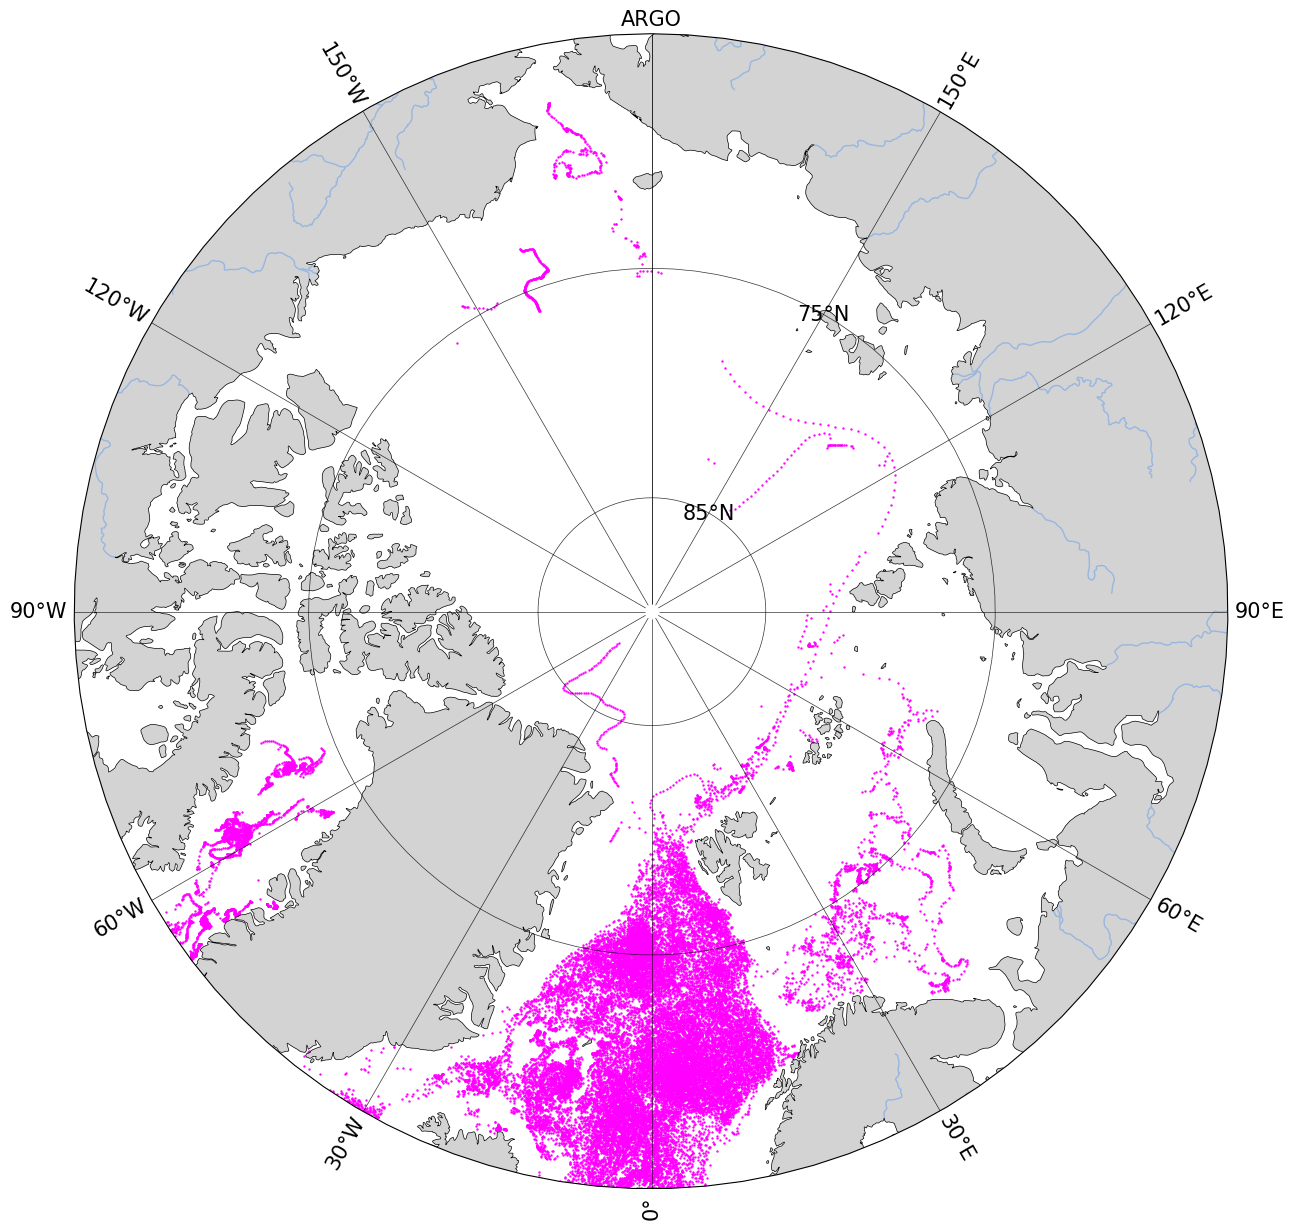

In [10]:


f,ax = plt.subplots(1,1,figsize=[15,15],subplot_kw={'projection': ccrs.NorthPolarStereo()})

ftz=15


Atools.plot_arctic_ax_map_new(ax)

ax.scatter(ds_argo_psal_test.longitude,
           ds_argo_psal_test.latitude,
           marker='.',transform=ccrs.PlateCarree(),s=2,color='magenta',label='All',alpha=1)
ax.set_title('ARGO',fontsize=ftz)


In [41]:
import pandas as pd

table = pd.DataFrame({
    "interpolated_position_file": interpolated_position_file,
    "n_qc8": n_qc8,
    "n_prof": n_prof,
    "ratio": np.round(np.array(n_qc8)/np.array(n_prof)*100,2)
    
})


table = table.sort_values("n_qc8", ascending=False)
table.to_csv(
    "qc8_table_argo_65N.csv",
    index=False,
    float_format="%.4f",    # lon/lat readable, not 1.23456789e+01
    sep=";",                # semicolon → Excel (French locale) opens cleanly
    encoding="utf-8-sig",   # BOM header → Excel detects UTF-8 without garbling
)

array([b'1', b'8', b'1', b'8', b'8', b'8', b'8', b'8', b'8', b'1', b'1',
       b'1', b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8',
       b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8',
       b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8',
       b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8',
       b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8',
       b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8',
       b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8',
       b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'1', b'8',
       b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8', b'8',
       b'1', b'8', b'1', b'1', b'1', b'1', b'9', b'9'], dtype=object)

In [15]:
# platform_num = 6903119

# df = pd.read_csv('/data0/user/aprigent/ARGO/estimate_profile_locations_' + str(platform_num) + '.csv',
#                          sep=";", index_col=False)
# ds_traj = xr.Dataset.from_dataframe(df)

# # Replace Argo lon/lat with corrected trajectory values
# cycle = ds_traj.CyNum.values
# lon_corr_6903119 = ds_traj.Lon.values
# lat_corr_6903119 = ds_traj.Lat.values

ds_6903119 = xr.open_dataset(argo_path+'6900654_prof.nc')

In [19]:
ds_6903119

<xarray.Dataset>
Dimensions:                       (N_PROF: 180, N_PARAM: 3, N_LEVELS: 71,
                                   N_CALIB: 1, N_HISTORY: 0)
Dimensions without coordinates: N_PROF, N_PARAM, N_LEVELS, N_CALIB, N_HISTORY
Data variables: (12/64)
    DATA_TYPE                     object ...
    FORMAT_VERSION                object ...
    HANDBOOK_VERSION              object ...
    REFERENCE_DATE_TIME           object ...
    DATE_CREATION                 object ...
    DATE_UPDATE                   object ...
    ...                            ...
    HISTORY_ACTION                (N_HISTORY, N_PROF) object ...
    HISTORY_PARAMETER             (N_HISTORY, N_PROF) object ...
    HISTORY_START_PRES            (N_HISTORY, N_PROF) float32 ...
    HISTORY_STOP_PRES             (N_HISTORY, N_PROF) float32 ...
    HISTORY_PREVIOUS_VALUE        (N_HISTORY, N_PROF) float32 ...
    HISTORY_QCTEST                (N_HISTORY, N_PROF) object ...
Attributes:
    title:                Argo float vertical profile
    institution:          FR GDAC
    source:               Argo float
    history:              2019-04-04T18:03:59Z creation
    references:           http://www.argodatamgt.org/Documentation
    user_manual_version:  3.1
    Conventions:          Argo-3.1 CF-1.6
    featureType:          trajectoryProfile

In [17]:
ds_6903119.LATITUDE.values.max()

66.275

Text(0.5, 1.0, 'ARGO')

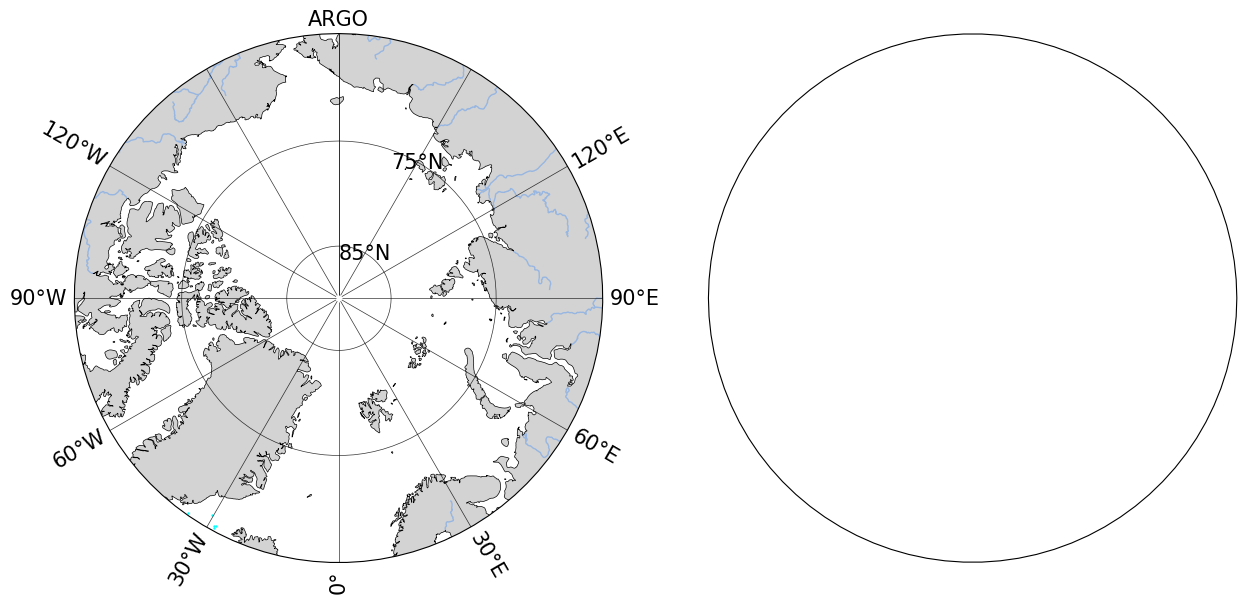

In [18]:

f,ax = plt.subplots(1,2,figsize=[15,10],subplot_kw={'projection': ccrs.NorthPolarStereo()})
ax=ax.ravel()
ftz=15
# cmap = cmocean.cm.deep
# levels = np.arange(-5000,500,500)



Atools.plot_arctic_ax_map_new(ax[0])

ax[0].scatter(ds_6903119.LONGITUDE,ds_6903119.LATITUDE,
           marker='.',transform=ccrs.PlateCarree(),s=2,color='cyan',label='All',alpha=1)
ax[0].set_title('ARGO',fontsize=ftz)

# ax[0].scatter(lon_corr_6903119,lat_corr_6903119,
#            marker='.',transform=ccrs.PlateCarree(),s=2,color='magenta',label='All',alpha=1)



In [11]:

    
def plot_vertical_distribution(ds_psal, ds_temp, source):

    ftz = 15

    sal = ds_psal.salinity.values
    temp = ds_temp.temperature.values
    depth = ds_psal.depth.values

    n_prof_psal = sal.shape[0]
    n_prof_temp = temp.shape[0]

    finite_per_level_psal = np.sum(np.isfinite(sal), axis=0)
    psal_mean = np.nanmedian(sal, axis=0)
    psal_std = np.nanstd(sal, axis=0)

    finite_per_level_temp = np.sum(np.isfinite(temp), axis=0)
    temp_mean = np.nanmedian(temp, axis=0)
    temp_std = np.nanstd(temp, axis=0)

    f, ax = plt.subplots(2, 2, figsize=[10, 10], sharey=True)
    ax = ax.ravel()
    plt.subplots_adjust(top=1, bottom=0, left=0, right=1, hspace=0.3)
    # ---- SALINITY PROFILES (NO LOOP) ----
    ax[0].scatter(
        sal.ravel(),
        np.tile(depth, n_prof_psal),
        s=1,
        color='blue'
    )

    ax[0].plot(psal_mean, depth, color='red', label=r'median')
    ax[0].plot(psal_mean + psal_std, depth, 'g--', label=r'median $\pm \sigma$')
    ax[0].plot(psal_mean - psal_std, depth, 'g--')
    ax[0].plot(psal_mean + 2*psal_std, depth, 'r--', label=r'median $\pm 2\sigma$')
    ax[0].plot(psal_mean - 2*psal_std, depth, 'r--')

    ax[0].invert_yaxis()
    ax[0].set_ylim([3000, 0])
    ax[0].legend(fontsize=ftz)
    ax[0].set_xlabel("Salinity",fontsize=ftz)
    ax[0].set_ylabel("Depth (m)",fontsize=ftz)
    ax[0].tick_params(labelsize=ftz)
    ax[0].set_title(source,fontsize=ftz)

    # ---- FINITE SALINITY ----
    ax[1].plot(finite_per_level_psal, depth, marker='.', color='black')
    ax[1].set_xlabel("Number of finite values",fontsize=ftz)
    ax[1].tick_params(labelsize=ftz)
    ax11 = ax[1].twiny()
    ax11.plot(finite_per_level_psal / n_prof_psal * 100, depth, color='black')
    ax11.set_xlabel("Fraction valid (%)",fontsize=ftz)
    ax11.tick_params(labelsize=ftz)

    # ---- TEMPERATURE PROFILES (NO LOOP) ----
    ax[2].scatter(
        temp.ravel(),
        np.tile(depth, n_prof_temp),
        s=1,
        color='blue'
    )

    ax[2].plot(temp_mean, depth, color='red', label=r'median')
    ax[2].plot(temp_mean + temp_std, depth, 'g--', label=r'median $\pm \sigma$')
    ax[2].plot(temp_mean - temp_std, depth, 'g--')
    ax[2].plot(temp_mean + 2*temp_std, depth, 'r--', label=r'median $\pm 2\sigma$')
    ax[2].plot(temp_mean - 2*temp_std, depth, 'r--')
    ax[2].set_xlabel("Temperature ($^{\circ}$C)",fontsize=ftz)
    ax[2].set_ylabel("Depth (m)",fontsize=ftz)
    ax[2].axvline(-2,color='magenta',linestyle='--')
    ax[2].legend(fontsize=ftz)
    ax[2].tick_params(labelsize=ftz)
    ax[2].set_title(source,fontsize=ftz)
    ax[2].invert_yaxis()
    ax[2].set_ylim([3000,0])

    # ---- FINITE TEMP ----
    ax[3].plot(finite_per_level_temp, depth, marker='.', color='black')
    ax[3].set_xlabel("Number of finite values",fontsize=ftz)
    ax[3].tick_params(labelsize=ftz)
    ax33 = ax[3].twiny()
    ax33.plot(finite_per_level_temp / n_prof_temp * 100, depth, color='black')
    ax33.set_xlabel("Fraction valid (%)",fontsize=ftz)
    ax33.tick_params(labelsize=ftz)
    return f